In [13]:
import sys
from pathlib import Path

sys.path.append(str(Path("..") / "src"))

In [14]:
import json
from run_fit import run

project_root = Path("..").resolve()
session_config_path = project_root / "data" / "session_config.json"

with open(session_config_path, "r", encoding="utf-8") as f:
    session_config = json.load(f)


n_components = int(session_config["n_components"])
config_path = session_config["config_path"]

print("Selected number of components:", n_components)
print("Using config:", config_path)


x_final, summary = run(config_path, n_components=n_components)

Selected number of components: 4
Using config: /Users/marcotamburi/projects/uni_project/svd_matrix_project/configs/fit4_config.json


# Fit summary

{'run_timestamp': '2026-06-16 17:17:23',
 'config_path': '/Users/marcotamburi/projects/uni_project/svd_matrix_project/configs/fit4_config.json',
 'n_components': 4,
 'stage1_success': True,
 'stage1_cost': 1.0640670997277721,
 'stage2_success': True,
 'stage2_cost': 1.0150371968940979,
 'T_shape': [41],
 'V_prime_shape': [4, 41],
 'U_prime_shape': [221, 4],
 'spectral_matrix_shape': [221, 41],
 'wavelengths_shape': [221],
 'preprocess_coeffs': {'C11': -0.1073619870022215,
  'C21': -0.4784433205633,
  'C31': -2.5117368315115147,
  'C41': 1.3670907929584553,
  'C14': -0.013201432784376781,
  'C24': -0.006454006602825753,
  'C34': -0.0588542354966695,
  'C44': 0.08338704226478394},
 'output_dir': '/Users/marcotamburi/projects/uni_project/svd_matrix_project/results/fit4_run/fit4_2026-06-16_17-17-23',
 'final_params': {'Tm1': 293.000000000013,
  'dTm12': 14.33136634545797,
  'dTm23': 99.99999999999999,
  'dH1': -1000.0000000000001,
  'dH2': -40925.46055184226,
  'dH3': -49999.999999999774,


## Output directory

/Users/marcotamburi/projects/uni_project/svd_matrix_project/results/fit4_run/fit4_2026-06-16_17-17-23


## Preprocessing - folded spectrum

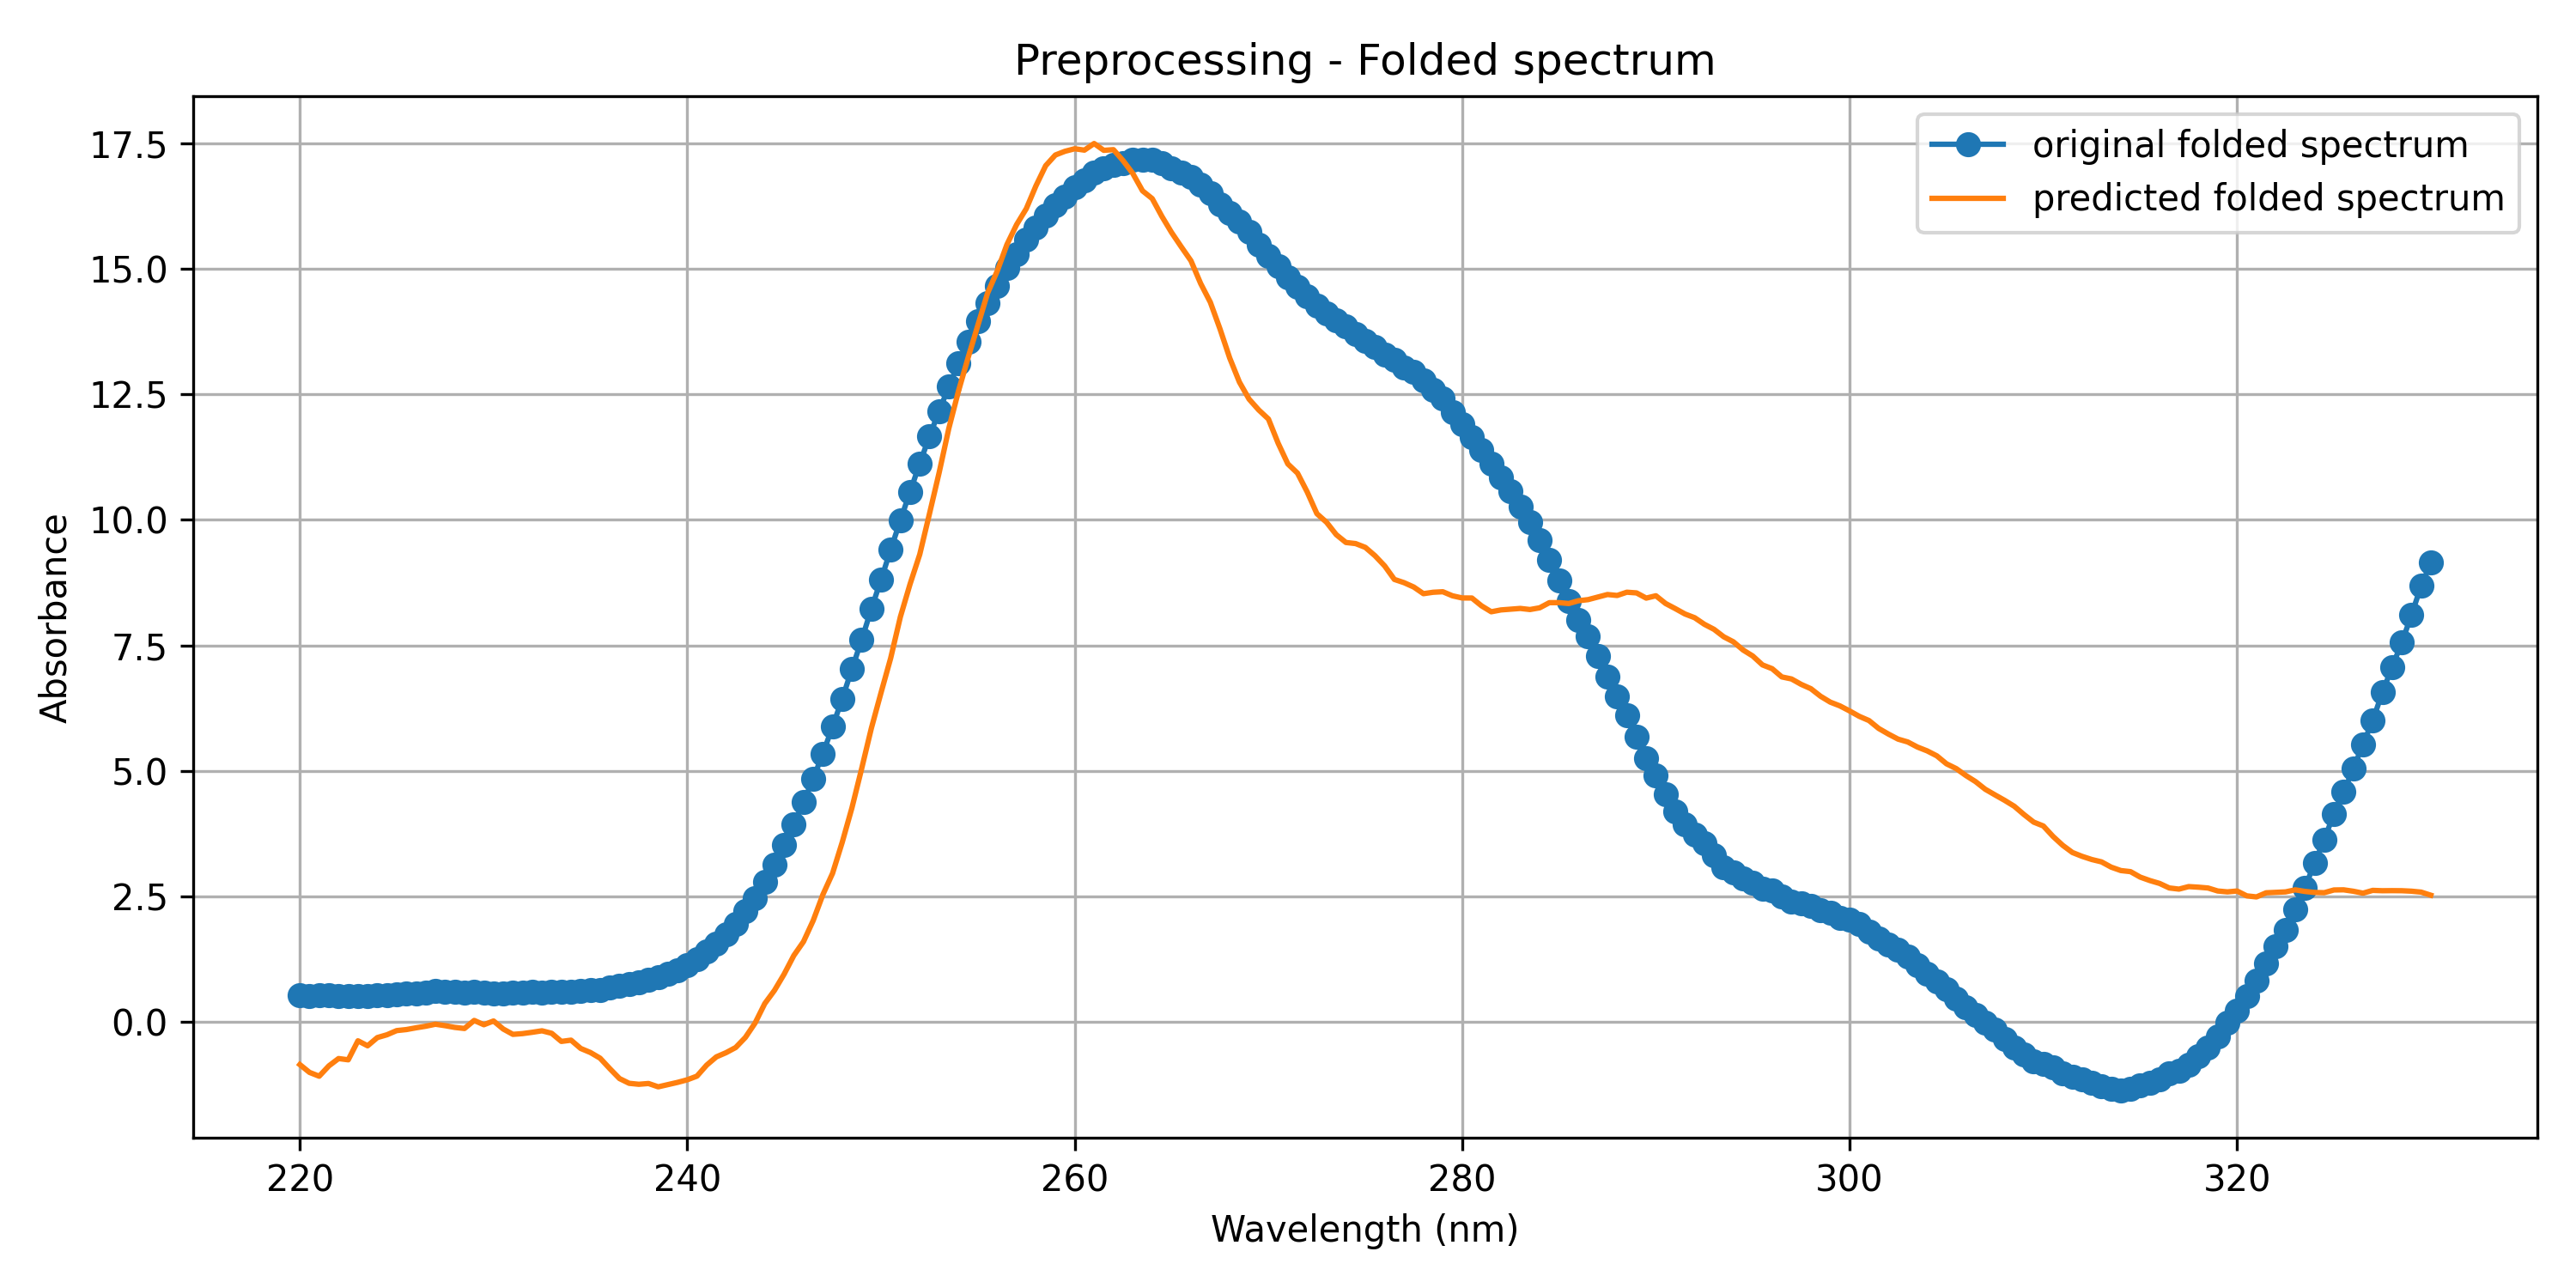

## Preprocessing - unfolded spectrum

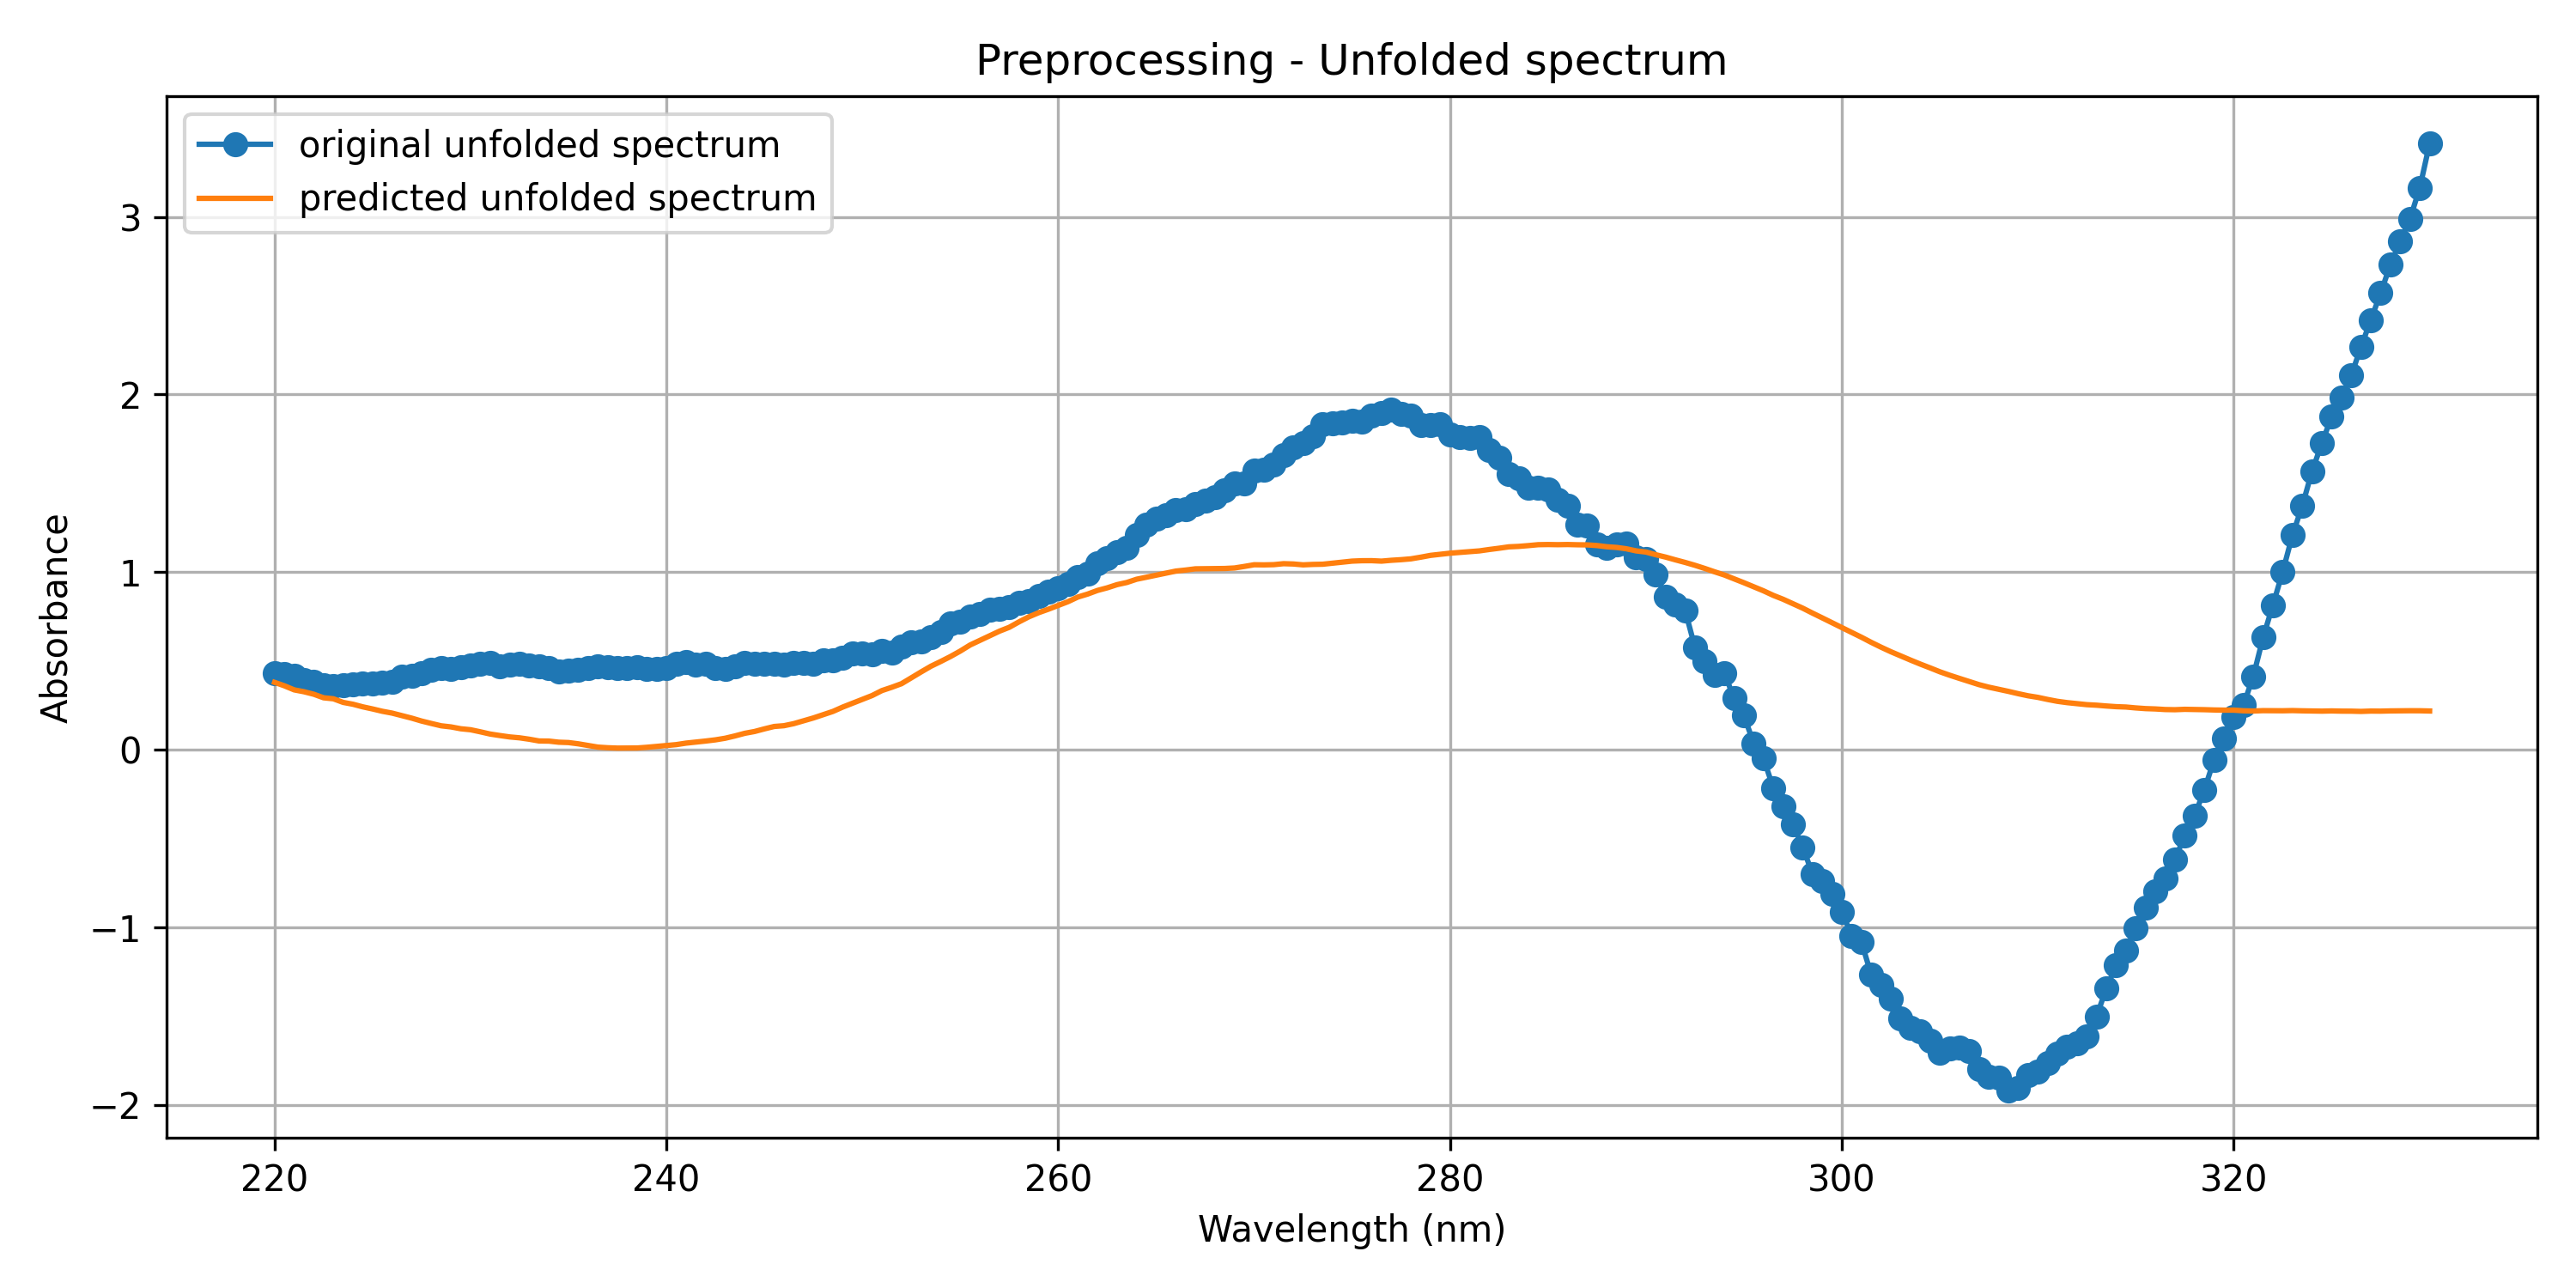

## Stage 1 global fit

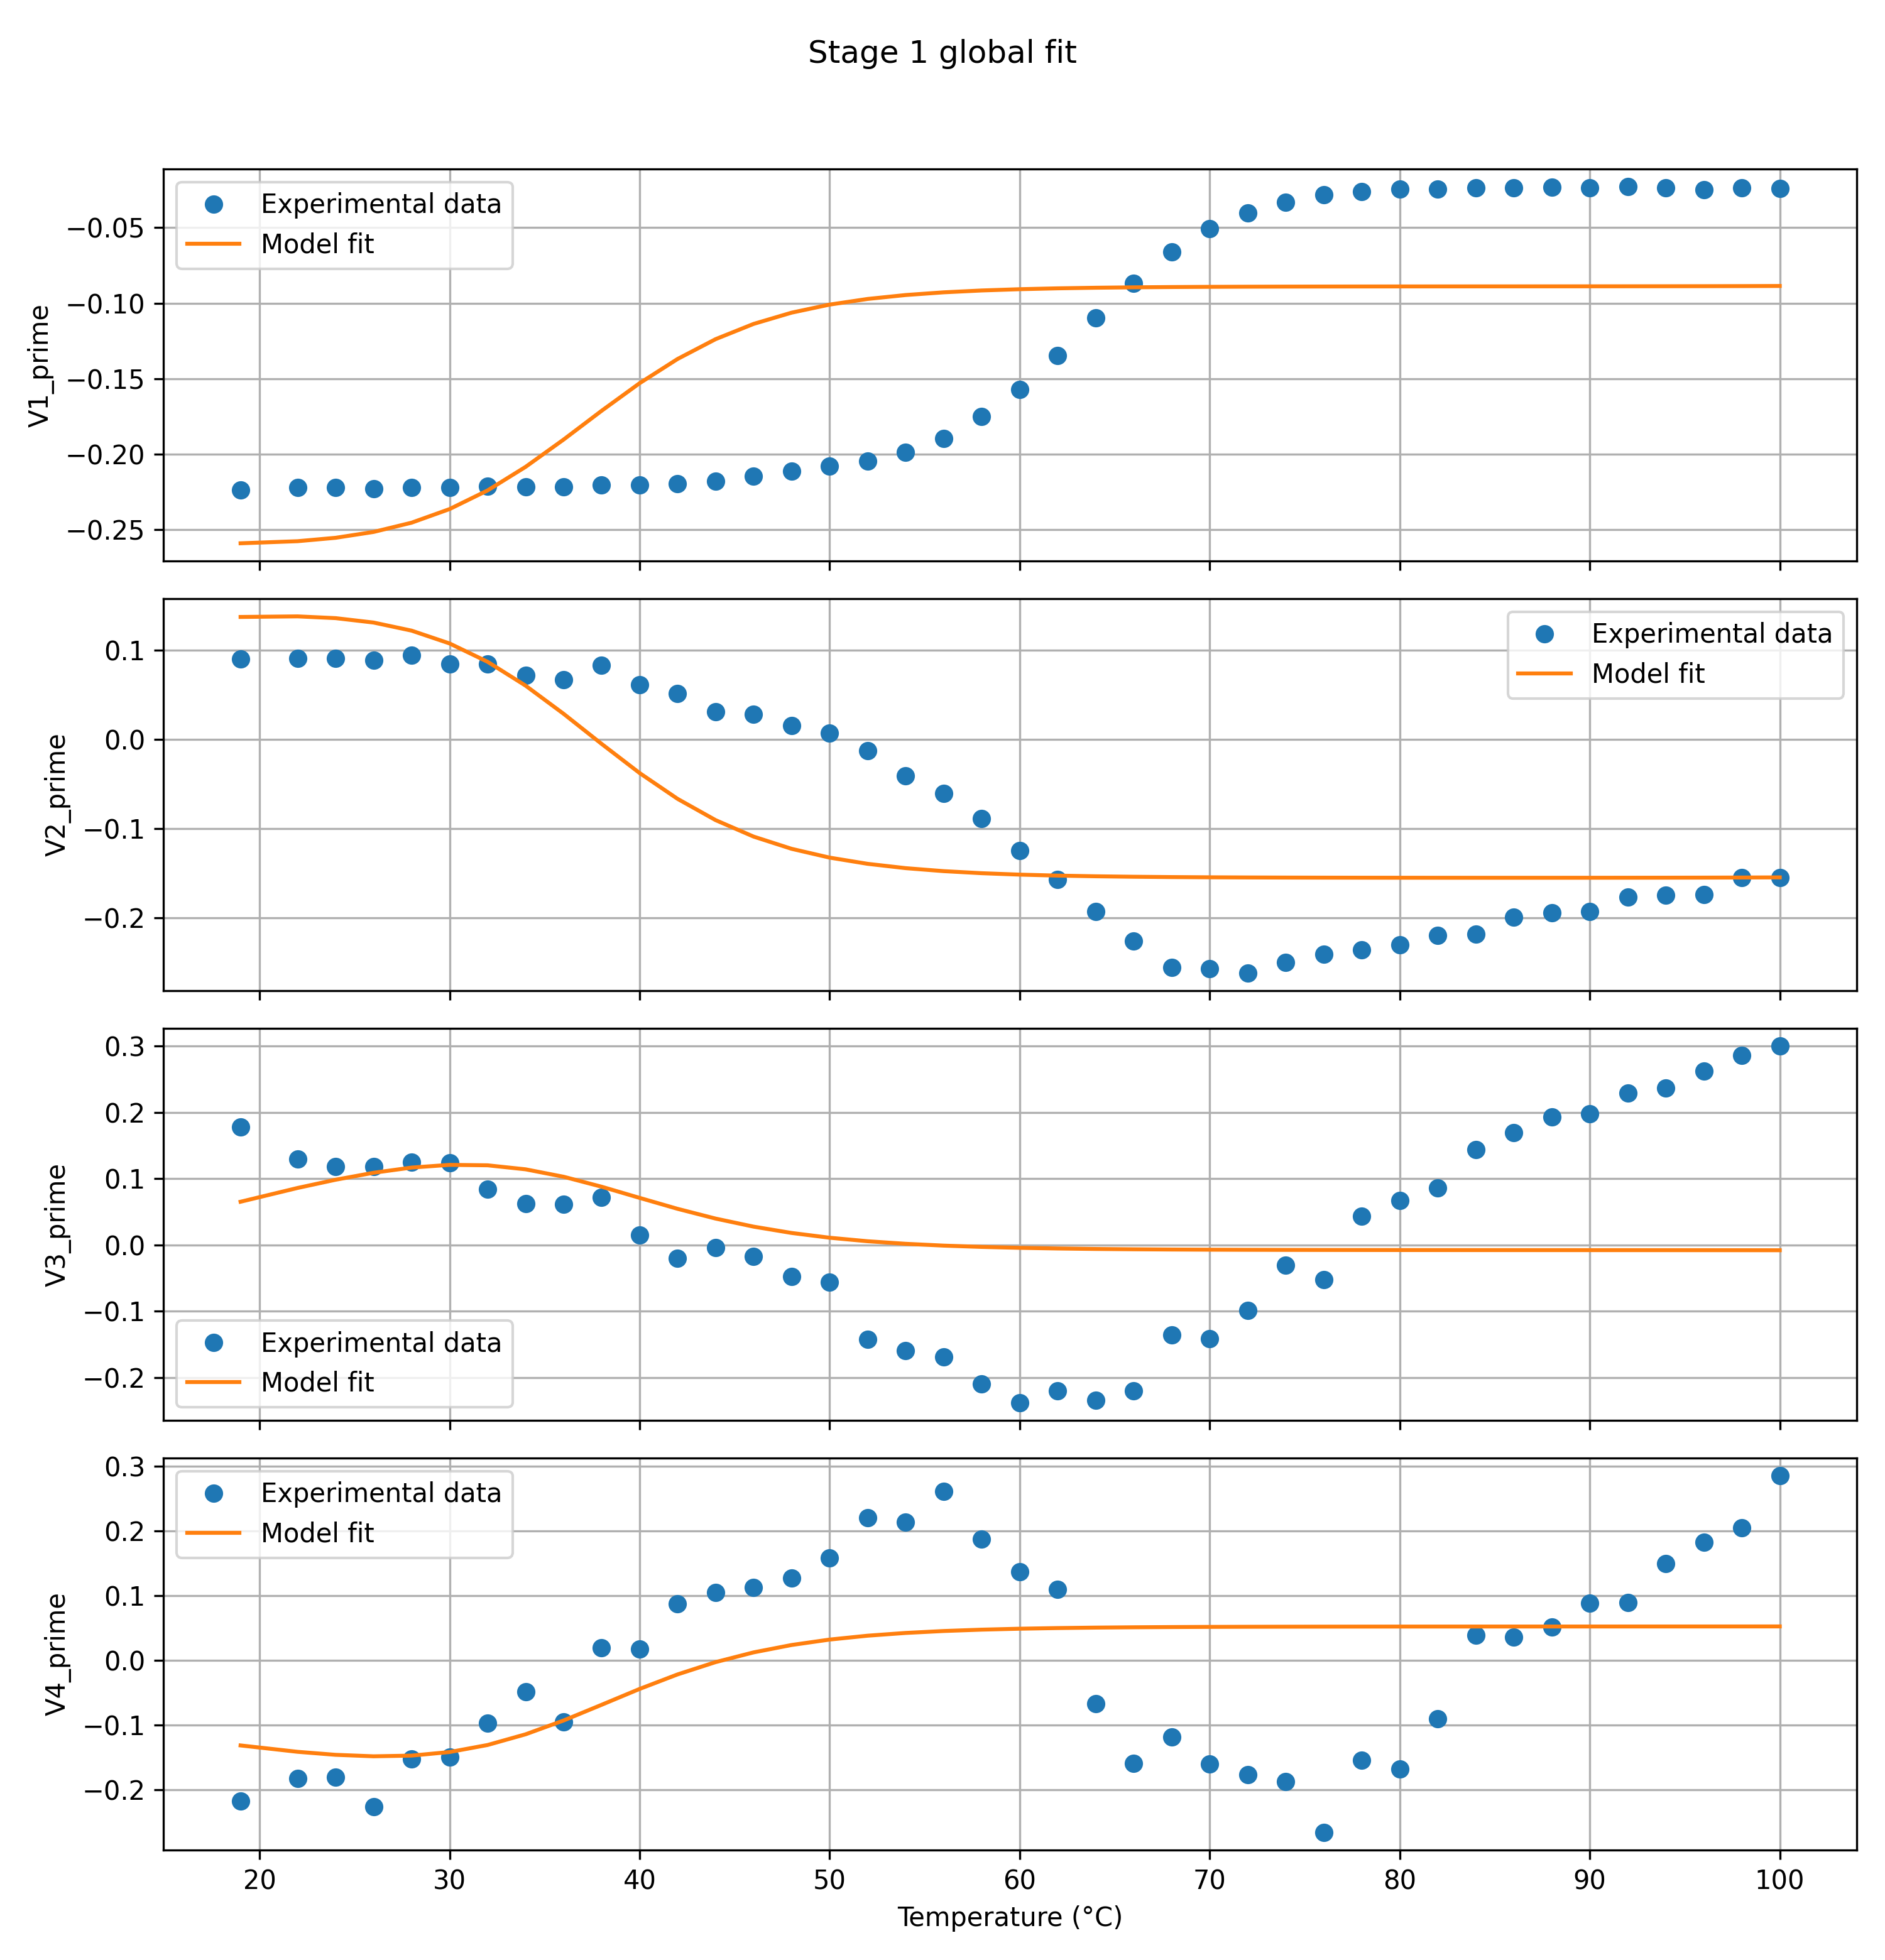

## Final global fit

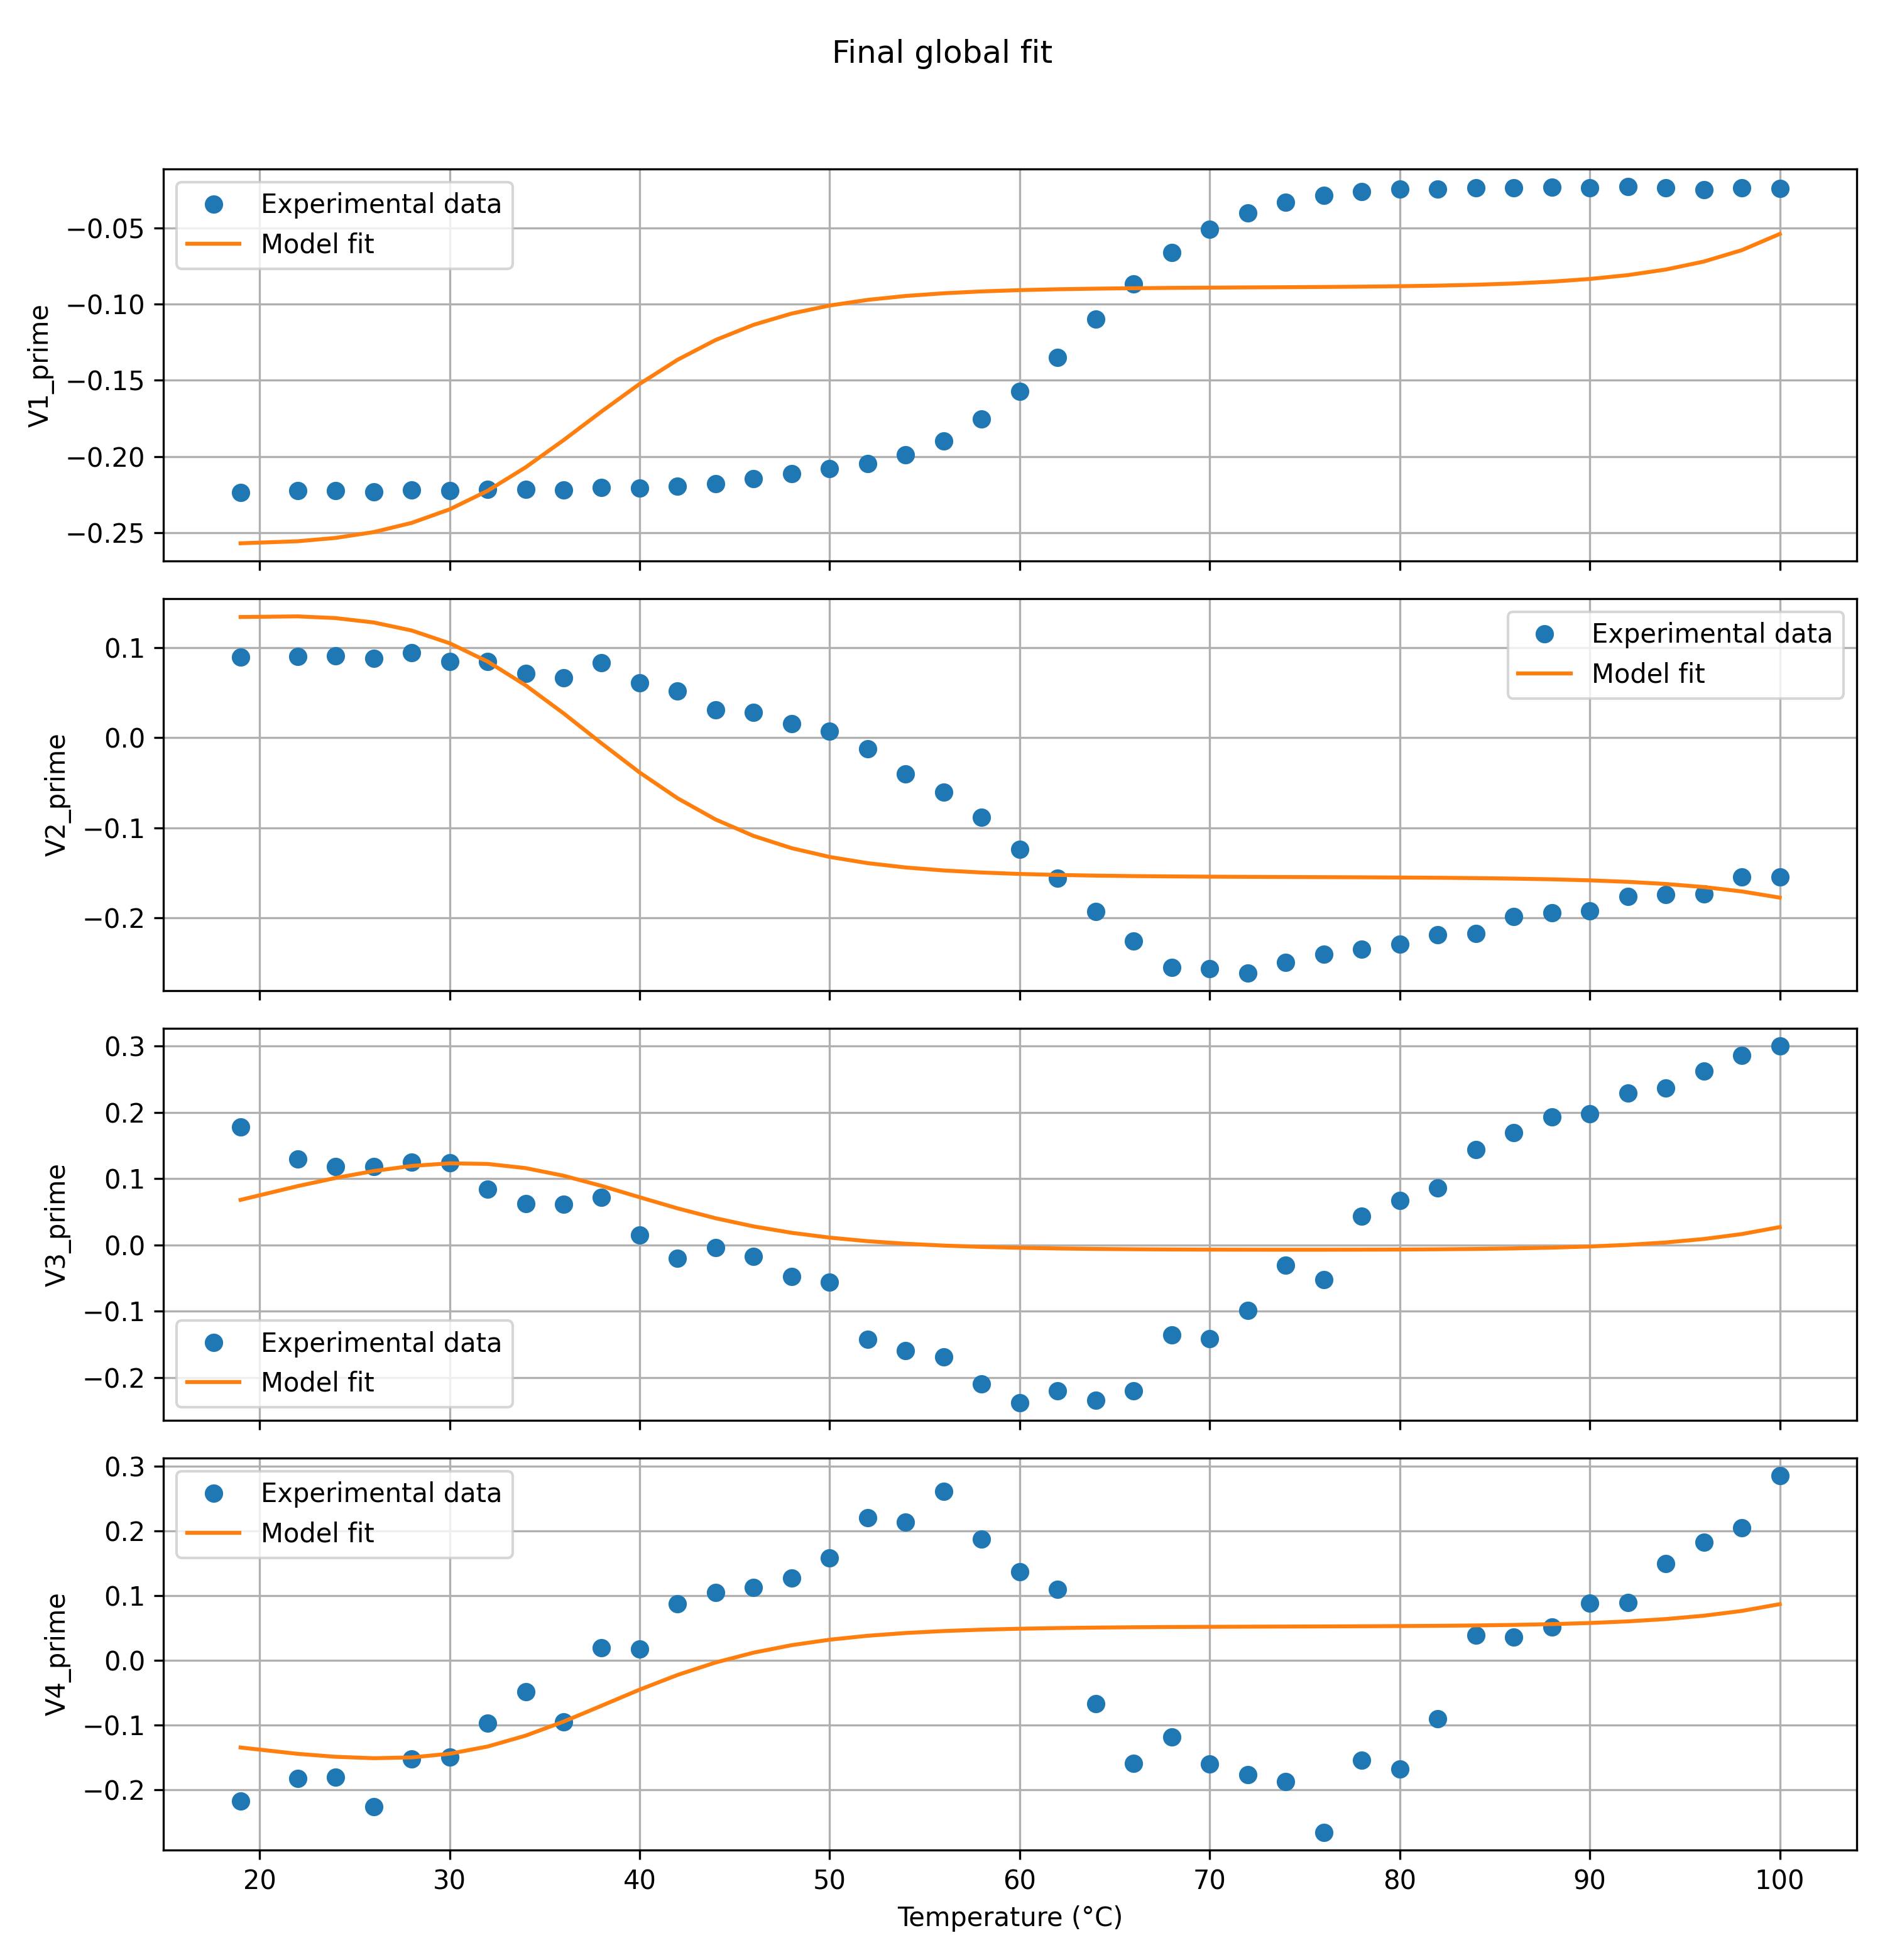

## Final parameters

File params_final.csv non trovato.


In [10]:
from pathlib import Path
from IPython.display import Image, display, Markdown
import pandas as pd

out_dir = Path(summary["output_dir"])

display(Markdown("# Fit summary"))
display(summary)

display(Markdown("## Output directory"))
print(out_dir)

plot_files = [
    ("Preprocessing - folded spectrum", out_dir / "preprocess_folded_fit.png"),
    ("Preprocessing - unfolded spectrum", out_dir / "preprocess_unfolded_fit.png"),
    ("Stage 1 global fit", out_dir / "stage1_global_fit.png"),
    ("Final global fit", out_dir / "final_global_fit.png"),
]

for title, plot_path in plot_files:
    display(Markdown(f"## {title}"))
    if plot_path.exists():
        display(Image(filename=str(plot_path)))
    else:
        print(f"File non trovato: {plot_path.name}")

params_final_path = out_dir / "params_final.csv"
if params_final_path.exists():
    display(Markdown("## Final parameters"))
    display(pd.read_csv(params_final_path))
else:
    display(Markdown("## Final parameters"))
    print("File params_final.csv non trovato.")

In [ ]:
import pandas as pd
from pathlib import Path

out_dir = Path(summary["output_dir"])

df_stage1 = pd.read_csv(out_dir / "stage1_fit_curves.csv")
df_final = pd.read_csv(out_dir / "final_fit_curves.csv")

df_stage1.head(), df_final.head()

(   T_kelvin  T_celsius    V1_exp    V1_fit  V1_resid    V2_exp    V2_fit  \
 0    292.15       19.0 -0.223733 -0.150550 -0.073183  0.089938 -0.112691   
 1    295.15       22.0 -0.222227 -0.149276 -0.072951  0.090482 -0.109266   
 2    297.15       24.0 -0.222392 -0.148420 -0.073972  0.090960 -0.107040   
 3    299.15       26.0 -0.223066 -0.147558 -0.075507  0.088463 -0.104859   
 4    301.15       28.0 -0.222065 -0.146693 -0.075372  0.094412 -0.102724   
 
    V2_resid    V3_exp    V3_fit  V3_resid  
 0  0.202629  0.178291 -0.116839  0.295130  
 1  0.199748  0.130111 -0.101398  0.231509  
 2  0.198000  0.118297 -0.091486  0.209783  
 3  0.193322  0.118222 -0.081872  0.200094  
 4  0.197136  0.124559 -0.072549  0.197108  ,
    T_kelvin  T_celsius    V1_exp    V1_fit  V1_resid    V2_exp    V2_fit  \
 0    292.15       19.0 -0.223733 -0.260940  0.037206  0.089938  0.153016   
 1    295.15       22.0 -0.222227 -0.253471  0.031244  0.090482  0.129910   
 2    297.15       24.0 -0.222392 